In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image=cv2.imread("00-puppy.jpg")
fix_img=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

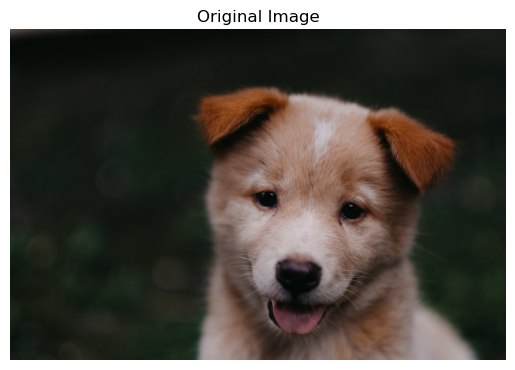

In [3]:
plt.imshow(fix_img)
plt.title("Original Image")
plt.axis("off")
plt.show()

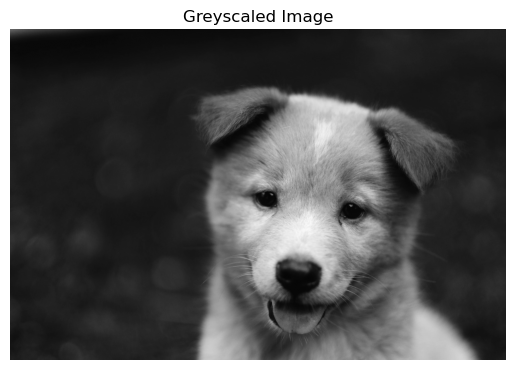

In [4]:
gr_img = cv2.imread("00-puppy.jpg",0) 
plt.imshow(gr_img, cmap='gray')
plt.title("Greyscaled Image")
plt.axis("off")
plt.show()

## Intensity Transformation

Negative(Linear) Transformation

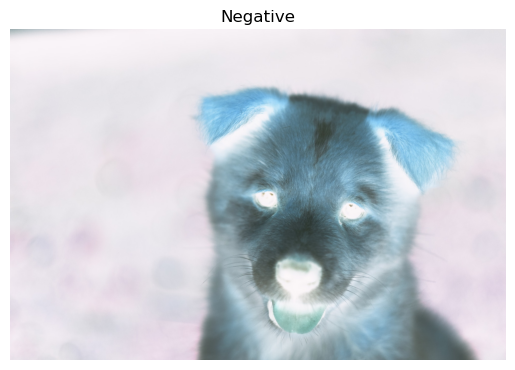

In [5]:
negative = 255 - fix_img

plt.imshow(negative)
plt.title("Negative")
plt.axis("off")
plt.show()

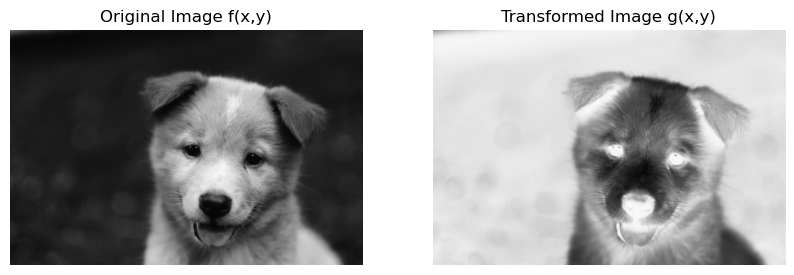

In [6]:
negative = 255 - gr_img

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gr_img, cmap='gray')
plt.title("Original Image f(x,y)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(negative, cmap='gray')
plt.title("Transformed Image g(x,y)")
plt.axis('off')

plt.show()

Log Transformation

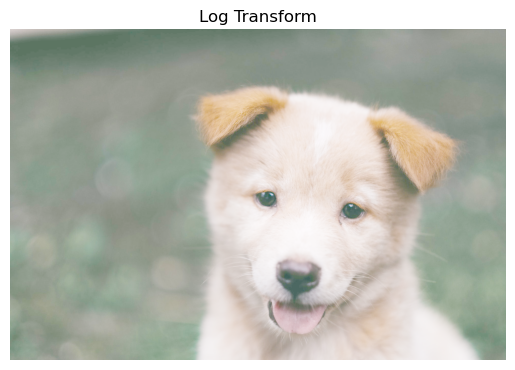

In [7]:
log_img = np.log1p(fix_img)
log_img = (255 * log_img / np.max(log_img)).astype(np.uint8)

plt.imshow(log_img)
plt.title("Log Transform")
plt.axis("off")
plt.show()

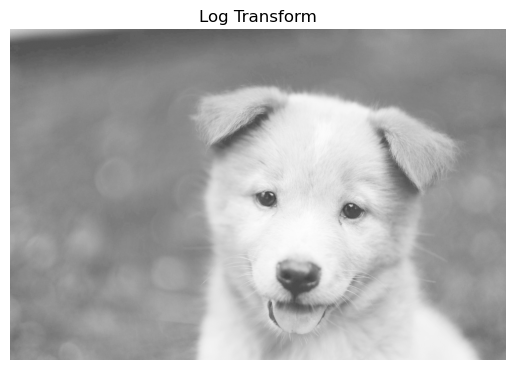

In [8]:
log_img = np.log1p(gr_img)
log_img = (255 * log_img / np.max(log_img)).astype(np.uint8)

plt.imshow(log_img,cmap='gray')
plt.title("Log Transform")
plt.axis("off")
plt.show()

Gamma Transformation

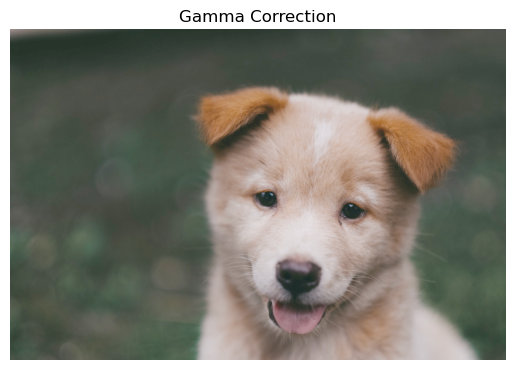

In [9]:
gamma = 0.5   # <1 brightens, >1 darkens

gamma_img = np.power(fix_img/255.0, gamma)
gamma_img = np.uint8(gamma_img*255)

plt.imshow(gamma_img)
plt.title("Gamma Correction")
plt.axis("off")
plt.show()

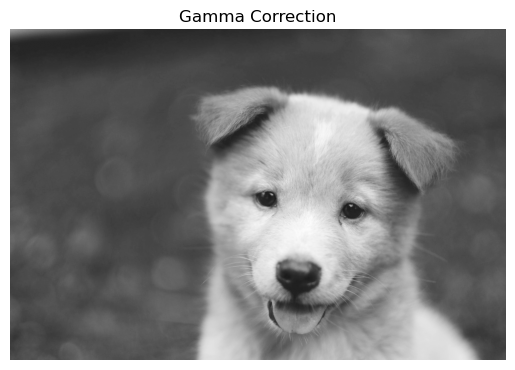

In [10]:
gamma = 0.5   # <1 brightens, >1 darkens

gamma_img = np.power(gr_img/255.0, gamma)
gamma_img = np.uint8(gamma_img*255)

plt.imshow(gamma_img, cmap='gray')
plt.title("Gamma Correction")
plt.axis("off")
plt.show()

Fourier Transformation

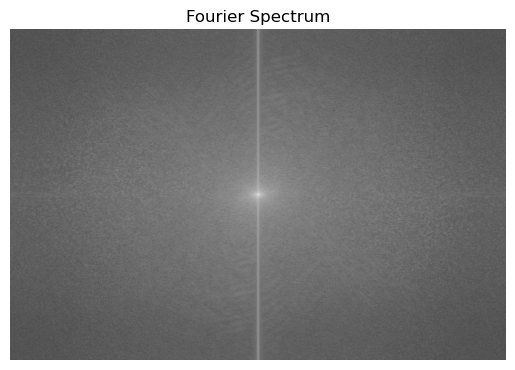

In [11]:
fourier = cv2.dft(np.float32(gr_img), flags=cv2.DFT_COMPLEX_OUTPUT)
fshift = np.fft.fftshift(fourier)

magnitude = 20*np.log(cv2.magnitude(fshift[:,:,0],fshift[:,:,1]))
magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8UC1)

plt.imshow(magnitude, cmap='gray')
plt.title("Fourier Spectrum")
plt.axis("off")
plt.show()

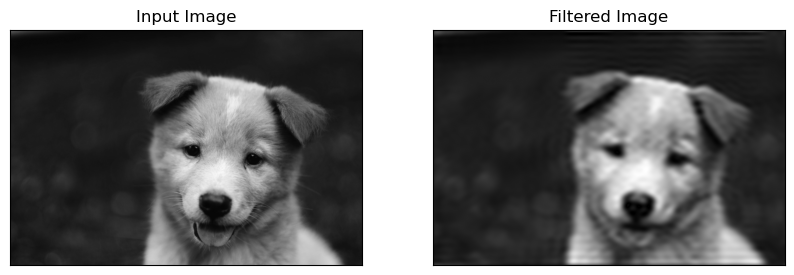

In [12]:
DFT = cv2.dft(np.float32(gr_img), flags=cv2.DFT_COMPLEX_OUTPUT)

shift = np.fft.fftshift(DFT)
row, col = gr_img.shape
center_row, center_col = row // 2, col // 2

mask = np.zeros((row, col, 2), np.uint8)
mask[center_row - 30:center_row + 30, center_col - 30:center_col + 30] = 1

fft_shift = shift * mask
fft_ifft_shift = np.fft.ifftshift(fft_shift)
imageThen = cv2.idft(fft_ifft_shift)

imageThen = cv2.magnitude(imageThen[:,:,0], imageThen[:,:,1])

plt.figure(figsize=(10,10))
plt.subplot(121), plt.imshow(gr_img, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(imageThen, cmap='gray')
plt.title('Filtered Image'), plt.xticks([]), plt.yticks([])
plt.show()